# Modelo definitivo para la predicción de rangos salariales

En este notebook desarrollamos la versión definitiva de LightGBM seleccionada en la comparación de alternativas. El propósito es estimar el salario mínimo (`Y1`) y máximo (`Y2`) anual en dólares estadounidenses, controlar la coherencia de los resultados y revisar su comportamiento frente a la geografía, la experiencia y las habilidades solicitadas.

La unidad de análisis continúa siendo la vacante publicada. El experimento utiliza únicamente rangos reportados por las empresas y conserva una separación temporal entre entrenamiento, validación y prueba. La búsqueda y la comparación de familias pertenecen al notebook 05; aquí se recibe una sola configuración de LightGBM, se revisa su estabilidad y se evalúa una vez sobre el periodo reservado.


## 0. Alcance y recorrido del modelado

Partimos de los criterios definidos en la exploración y de la comparación realizada en el notebook 05. LightGBM fue seleccionado dentro del grupo de alternativas con MAE promedio equivalente en términos prácticos, al obtener el menor error para el límite salarial superior y mantener compatibilidad con el pipeline productivo.

Este notebook no vuelve a ajustar hiperparámetros ni prueba Random Forest u otras familias. Recupera la mejor instancia de LightGBM, la entrena con las mismas variables, transformación del objetivo y partición temporal, y verifica su desempeño frente a una línea base. Después realiza un retrotest para revisar subajuste y sobreajuste, conserva la prueba más reciente sin observar hasta el final y analiza resultados por país, experiencia, modalidad y conocimientos.


## 1. Preparación del entorno de análisis

Configuramos las librerías, la semilla y el estilo visual con la misma presentación utilizada en el análisis exploratorio. La dirección de MLflow se lee desde el archivo local `ml/.env`; no se almacena ni se imprime en el notebook. El experimento se reutiliza cuando está activo, se restaura si fue eliminado y se crea cuando no existe.

Al comenzar se eliminan únicamente las corridas activas creadas por ejecuciones anteriores de este notebook. De esta forma no se borran las corridas comparativas del notebook 05. Las pruebas de validación y retrotest conservan nombres descriptivos, mientras que la corrida final de prueba se publica con el nombre `champion`.


In [1]:
from pathlib import Path
from urllib.parse import urldefrag
import json, os, re, sys, warnings
import joblib, mlflow, mlflow.sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from dotenv import load_dotenv
from IPython.display import display
from matplotlib import font_manager
from mlflow.entities import ViewType
from mlflow.tracking import MlflowClient
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import TargetEncoder
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')
os.environ.setdefault('MLFLOW_SUPPRESS_PRINTING_URL_TO_STDOUT', 'true')
os.environ.setdefault('MLFLOW_PRINT_MODEL_URLS_ON_CREATION', 'false')
SEED = 42
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
DATA_DIR, ARTIFACT_DIR = (
    ROOT / "data" / "raw" / "foorilla",
    ROOT / "artifacts",
)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
font_files = list((ROOT/'assets'/'fonts').glob('DroidSerif-*.ttf'))
for font_file in font_files: font_manager.fontManager.addfont(font_file)
plt.rcParams.update({'font.family':'Droid Serif' if font_files else 'serif','figure.dpi':120,
                     'axes.spines.top':False,'axes.spines.right':False})
sns.set_theme(style='whitegrid', palette='Blues_d', font='Droid Serif' if font_files else 'serif')
load_dotenv(ROOT/'.env',override=False)
TRACKING_URI=os.getenv('MLFLOW_TRACKING_URI','').strip().rstrip('/')
if not TRACKING_URI:
    raise EnvironmentError('Configure MLFLOW_TRACKING_URI en el archivo local ml/.env antes de ejecutar el notebook.')
if not TRACKING_URI.startswith(('http://','https://')):
    raise ValueError('MLFLOW_TRACKING_URI debe incluir el protocolo http:// o https://.')
EXPERIMENT_NAME=os.getenv('MLFLOW_EXPERIMENT_NAME','salary-prediction')
REGISTERED_MODEL_NAME=os.getenv('MLFLOW_MODEL_NAME','salary-predictor')
PRODUCTION_ALIAS=os.getenv('MLFLOW_MODEL_ALIAS','champion')
LOG_MODELS_TO_MLFLOW=os.getenv('LOG_MODELS_TO_MLFLOW','false').lower()=='true'
os.environ['MLFLOW_TRACKING_URI']=TRACKING_URI
os.environ['MLFLOW_EXPERIMENT_NAME']=EXPERIMENT_NAME
os.environ['MLFLOW_MODEL_NAME']=REGISTERED_MODEL_NAME
mlflow.set_tracking_uri(TRACKING_URI)
mlflow_client = MlflowClient(tracking_uri=TRACKING_URI)
RESET_NOTEBOOK_RUNS = os.getenv('MLFLOW_RESET_NOTEBOOK_RUNS', 'true').lower() == 'true'
NOTEBOOK_FLOW = 'notebook_06_modelo_definitivo'

def prepare_mlflow_experiment():
    try:
        experiments = mlflow_client.search_experiments(view_type=ViewType.ALL, max_results=10000)
    except Exception as error:
        raise ConnectionError(
            'No fue posible conectar con el servidor definido en MLFLOW_TRACKING_URI. Verifique la configuración y el acceso de red.'
        ) from error

    experiment = next((item for item in experiments if item.name == EXPERIMENT_NAME), None)
    if experiment is None:
        experiment_id = mlflow_client.create_experiment(EXPERIMENT_NAME)
        experiment_action = 'creado'
    else:
        experiment_id = experiment.experiment_id
        if experiment.lifecycle_stage == 'deleted':
            mlflow_client.restore_experiment(experiment_id)
            experiment_action = 'restaurado'
        else:
            experiment_action = 'reutilizado'

    mlflow.set_experiment(experiment_id=experiment_id)
    deleted_runs = 0
    if RESET_NOTEBOOK_RUNS:
        previous_runs = mlflow_client.search_runs(
            experiment_ids=[experiment_id],
            filter_string=f"tags.flujo = '{NOTEBOOK_FLOW}'",
            run_view_type=ViewType.ACTIVE_ONLY,
            max_results=50000,
        )
        for previous_run in previous_runs:
            mlflow_client.delete_run(previous_run.info.run_id)
        deleted_runs = len(previous_runs)
    return experiment_id, experiment_action, deleted_runs

EXPERIMENT_ID, EXPERIMENT_ACTION, DELETED_NOTEBOOK_RUNS = prepare_mlflow_experiment()
print({'python':sys.version.split()[0],'pandas':pd.__version__,'sklearn':sklearn.__version__,
       'mlflow':mlflow.__version__,'conexion_mlflow':'configurada_desde_entorno',
       'experimento':EXPERIMENT_NAME,'modelo_registrado':REGISTERED_MODEL_NAME,
       'alias_produccion':PRODUCTION_ALIAS,
       'registrar_modelos_intermedios':LOG_MODELS_TO_MLFLOW,'semilla':SEED})

{'python': '3.14.4', 'pandas': '3.0.5', 'sklearn': '1.8.0', 'mlflow': '3.16.0', 'conexion_mlflow': 'configurada_desde_entorno', 'experimento': 'salary-prediction', 'modelo_registrado': 'salary-predictor', 'alias_produccion': 'champion', 'registrar_modelos_intermedios': False, 'semilla': 42}


## 2. Integración, republicaciones y procedencia del objetivo

Integramos todos los cortes disponibles y conservamos la versión más reciente y completa de cada identificador. Después construimos una firma con URL, empresa, cargo y ubicación para retirar republicaciones. Y1 y Y2 se toman de los valores convertidos a USD y se clasifican como reportados, híbridos o estimados. Esta separación evita que el modelo principal aprenda principalmente el estimador de Foorilla.

In [2]:
files=sorted(DATA_DIR.glob('jobs_*.csv'))
assert files,'No se encontraron archivos data/jobs_*.csv'
parts=[]
for priority,path in enumerate(files):
    frame=pd.read_csv(path,low_memory=False)
    frame['_priority'],frame['_source_file']=priority,path.name
    parts.append(frame)
raw=pd.concat(parts,ignore_index=True)
raw['published']=pd.to_datetime(raw['published'],errors='coerce',utc=True)
raw['_complete']=raw.notna().sum(axis=1)
by_id=(raw.sort_values(['id','_priority','_complete','published'])
          .drop_duplicates('id',keep='last').copy())

def norm(values):
    return (values.fillna('').astype(str).str.lower().str.normalize('NFKD')
            .str.encode('ascii',errors='ignore').str.decode('ascii')
            .str.replace(r'[^a-z0-9]+',' ',regex=True).str.strip())

url=by_id.apply_url.fillna('').astype(str).map(lambda value:urldefrag(value)[0].rstrip('/').lower())
by_id['_signature']=url+'|'+norm(by_id.company)+'|'+norm(by_id.title)+'|'+norm(by_id.location)
by_id['_salary_info']=by_id[['salary_min','salary_max','salary_min_usd','salary_max_usd']].notna().sum(axis=1)
dedup=(by_id.sort_values(['_signature','company_is_agency','_salary_info','_complete','published'])
          .drop_duplicates('_signature',keep='last').copy())
for side in ['min','max']:
    dedup[f'y_{side}_usd']=pd.to_numeric(dedup[f'salary_{side}_usd'],errors='coerce')
    dedup[f'{side}_reported']=pd.to_numeric(dedup[f'salary_{side}'],errors='coerce').notna()
dedup['target_source']=np.select([dedup.min_reported&dedup.max_reported,
                                  dedup.min_reported|dedup.max_reported],
                                 ['reportado','híbrido'],default='estimado')
complete=dedup.y_min_usd.notna()&dedup.y_max_usd.notna()
positive=complete&(dedup.y_min_usd>0)&(dedup.y_max_usd>0)
ordered=positive&(dedup.y_min_usd<=dedup.y_max_usd)
candidate=dedup.loc[ordered].copy()
log_mid=np.log1p((candidate.y_min_usd+candidate.y_max_usd)/2)
q1,q3=log_mid.quantile([.25,.75]); inlier=log_mid.between(q1-3*(q3-q1),q3+3*(q3-q1))
model_df=candidate.loc[inlier].copy()
display(pd.Series({'filas_integradas':len(raw),'id_unicos':len(by_id),'vacantes_deduplicadas':len(dedup),
                   'y_incompleta':int((~complete).sum()),'y_no_positiva':int((complete&~positive).sum()),
                   'y_invertida':int((positive&~ordered).sum()),'extremos_retirados':int((~inlier).sum()),
                   'muestra_modelado':len(model_df),'rangos_reportados':int(model_df.target_source.eq('reportado').sum())}))

filas_integradas         338667
id_unicos                338281
vacantes_deduplicadas    287415
y_incompleta              23551
y_no_positiva                 5
y_invertida                  11
extremos_retirados           25
muestra_modelado         263823
rangos_reportados         55002
dtype: int64

## 3. Validación de Y1 y Y2 en los periodos temporales

Antes de entrenar verificamos que los nuevos valores objetivo permanezcan positivos, completos y ordenados. También comparamos tamaño, mediana y percentiles por partición. Una diferencia entre periodos no constituye fuga de información, pero sí puede explicar una reducción del desempeño fuera de entrenamiento y debe permanecer visible en la interpretación.

In [3]:
reported=model_df.loc[model_df.target_source.eq('reportado')].sort_values('published',na_position='first')
n=len(reported); a,b=int(.70*n),int(.85*n)
train_idx,val_idx,test_idx=reported.index[:a],reported.index[a:b],reported.index[b:]
split_map={**dict.fromkeys(train_idx,'entrenamiento'),**dict.fromkeys(val_idx,'validación'),
           **dict.fromkeys(test_idx,'prueba')}
reported['particion']=reported.index.map(split_map)
target_profile=(reported.groupby('particion',observed=True)
    .agg(n=('id','size'),fecha_inicial=('published','min'),fecha_final=('published','max'),
         y1_p05=('y_min_usd',lambda s:s.quantile(.05)),y1_mediana=('y_min_usd','median'),
         y1_p95=('y_min_usd',lambda s:s.quantile(.95)),y2_p05=('y_max_usd',lambda s:s.quantile(.05)),
         y2_mediana=('y_max_usd','median'),y2_p95=('y_max_usd',lambda s:s.quantile(.95))))
display(target_profile)
assert (reported.y_min_usd>0).all() and (reported.y_max_usd>0).all()
assert (reported.y_min_usd<=reported.y_max_usd).all()
train_limits={'floor':max(1000,float(reported.loc[train_idx,'y_min_usd'].quantile(.001))),
              'ceiling':float(reported.loc[train_idx,'y_max_usd'].quantile(.999))}
outside=pd.DataFrame({
    'particion':['validación','prueba'],
    'y1_fuera_soporte_train':[np.mean(~reported.loc[val_idx,'y_min_usd'].between(reported.loc[train_idx,'y_min_usd'].min(),reported.loc[train_idx,'y_min_usd'].max())),
                              np.mean(~reported.loc[test_idx,'y_min_usd'].between(reported.loc[train_idx,'y_min_usd'].min(),reported.loc[train_idx,'y_min_usd'].max()))],
    'y2_fuera_soporte_train':[np.mean(~reported.loc[val_idx,'y_max_usd'].between(reported.loc[train_idx,'y_max_usd'].min(),reported.loc[train_idx,'y_max_usd'].max())),
                              np.mean(~reported.loc[test_idx,'y_max_usd'].between(reported.loc[train_idx,'y_max_usd'].min(),reported.loc[train_idx,'y_max_usd'].max()))]})
display(outside.style.format({'y1_fuera_soporte_train':'{:.2%}','y2_fuera_soporte_train':'{:.2%}'}))
print('Límites operativos aprendidos solo con entrenamiento:',train_limits)

,n,fecha_inicial,fecha_final,y1_p05,y1_mediana,y1_p95,y2_p05,y2_mediana,y2_p95
particion,,,,,,,,,
entrenamiento,38501,2025-01-01 00:13:20+00:00,2026-03-04 00:00:00+00:00,55900.0,130000.0,224000.0,91783.0,200000.0,339000.0
prueba,8251,2026-06-02 00:00:00+00:00,2026-09-09 13:30:04+00:00,48446.0,128039.0,224493.5,68000.0,182300.0,336500.0
validación,8250,2026-03-04 00:00:00+00:00,2026-06-01 23:11:07+00:00,54000.0,132100.0,237820.0,75882.0,193200.0,361400.0


,particion,y1_fuera_soporte_train,y2_fuera_soporte_train
0,validación,0.01%,0.02%
1,prueba,0.01%,0.01%


Límites operativos aprendidos solo con entrenamiento: {'floor': 11438.0, 'ceiling': 720000.0}


## 4. Ingeniería de variables y categorías nuevas

Construimos las mismas variables definidas en el EDA: cargo, geografía, experiencia, modalidad, empresa, condición de agencia y habilidades. Si el ganador usa el preprocesamiento general, las categorías pasan por `TargetEncoder`, cuyo ajuste cruzado reduce el riesgo de memorizar empresas o cargos y asigna la media global ante valores nuevos. Si CatBoost resulta ganador, conserva su tratamiento categórico nativo. Cada objetivo ajusta sus transformaciones exclusivamente con entrenamiento.

In [4]:
SKILLS={'python':'python','sql':'sql','aws':'aws','azure':'azure','gcp':'gcp','spark':'spark',
        'docker':'docker','kubernetes':'kubernetes','machine_learning':'machine learning',
        'pytorch':'pytorch','tensorflow':'tensorflow','tableau':'tableau','power_bi':'power bi'}
def prepare_features(df):
    out=pd.DataFrame(index=df.index)
    out['title']=norm(df.title).replace('','desconocido')
    out['country']=df.countries.fillna('desconocido').astype(str).str.split('|').str[0].str.strip().replace('','desconocido')
    out['region']=df.regions.fillna('desconocido').astype(str).str.split('|').str[0].str.strip().replace('','desconocido')
    out['experience_level']=df.experience_level.fillna('desconocido').astype(str)
    remote=df.has_remote.fillna(False).astype(bool); work=pd.to_numeric(df.work_mode,errors='coerce')
    out['work_mode']=np.select([~remote,work.eq(1),work.eq(2),work.eq(3)],
                               ['presencial','híbrido','remoto','remoto_global'],default='remoto_sin_detalle')
    out['company']=norm(df.company).replace('','desconocido')
    out['company_is_agency']=df.company_is_agency.fillna(False).astype(int)
    years=pd.to_numeric(df.experience_years,errors='coerce')
    out['experience_years']=years.where(years.between(0,50))
    out['experience_years_missing']=out.experience_years.isna().astype(int)
    tags=df.tags.fillna('').astype(str).str.lower()
    for name,token in SKILLS.items():out[f'skill_{name}']=tags.str.contains(re.escape(token),regex=True).astype(int)
    out['published_year'],out['published_month']=df.published.dt.year,df.published.dt.month
    return out

X=prepare_features(model_df); TARGETS=['y_min_usd','y_max_usd']
cat_cols=['title','country','region','experience_level','work_mode','company']
num_cols=[column for column in X if column not in cat_cols]
assert not [column for column in X if 'salary' in column.lower()]
comparison_dir=ROOT/'artifacts'/'comparacion_modelos'
selection_path=comparison_dir/'seleccion_modelo.json'
best_models_path=comparison_dir/'mejor_configuracion_por_modelo.csv'
assert selection_path.exists() and best_models_path.exists(),(
    'Primero debe ejecutarse completamente notebooks/05_experimentos_modelos_fjlo.ipynb')
with open(selection_path) as file:comparison_contract=json.load(file)
comparison_contract.pop('mlflow_tracking_uri',None)
assert comparison_contract['feature_columns']==list(X.columns),'El contrato de variables cambió entre los notebooks 05 y 06'
assert comparison_contract['categorical_columns']==cat_cols,'Las variables categóricas no coinciden con el notebook 05'
assert comparison_contract['modelo_seleccionado']=='lightgbm',(
    'El notebook 05 debe seleccionar LightGBM mediante la regla documentada antes de continuar.')
best_models=pd.read_csv(best_models_path)
lightgbm_rows=best_models.loc[best_models.modelo.eq('lightgbm')].copy()
assert len(lightgbm_rows)==1,'Debe existir una única mejor configuración de LightGBM en el notebook 05'
lightgbm_row=lightgbm_rows.iloc[0]
selected_model='lightgbm'
winner=str(lightgbm_row.configuracion)
selected_params=json.loads(lightgbm_row.parametros)
comparison_selection={'modelo_seleccionado':selected_model,
                      'configuracion_seleccionada':winner,
                      'parametros':selected_params,
                      'preprocesamiento':'TargetEncoder',
                      'feature_columns':list(X.columns),
                      'categorical_columns':cat_cols,
                      'numeric_columns':num_cols,
                      'criterio_aplicado':comparison_contract.get('criterio_seleccion','selección documentada en notebook 05'),
                      'tracking_uri_source':'MLFLOW_TRACKING_URI'}
display(pd.DataFrame([{'modelo':selected_model,'configuracion':winner,
                       'mae_min_notebook_05':lightgbm_row.mae_min,
                       'mae_max_notebook_05':lightgbm_row.mae_max,
                       'mae_promedio_notebook_05':lightgbm_row.mae_promedio,
                       'hiperparámetros':json.dumps(selected_params,ensure_ascii=False)}]).style.format({
    'mae_min_notebook_05':'USD {:,.0f}','mae_max_notebook_05':'USD {:,.0f}',
    'mae_promedio_notebook_05':'USD {:,.0f}'}))
novelty=[]
for column in cat_cols:
    known=set(X.loc[train_idx,column])
    for label,index in [('validación',val_idx),('prueba',test_idx)]:
        novelty.append({'variable':column,'particion':label,'categorias_train':len(known),
                        'categorias_nuevas':len(set(X.loc[index,column])-known),
                        'filas_categoria_nueva':np.mean(~X.loc[index,column].isin(known))})
novelty=pd.DataFrame(novelty)
display(novelty.style.format({'filas_categoria_nueva':'{:.1%}'}))


,modelo,configuracion,mae_min_notebook_05,mae_max_notebook_05,mae_promedio_notebook_05,hiperparámetros
0,lightgbm,lightgbm__03,"USD 23,104","USD 32,009","USD 27,556","{""objective"": ""regression_l1"", ""verbosity"": -1, ""subsample_freq"": 1, ""subsample"": 0.8, ""reg_lambda"": 6.0, ""reg_alpha"": 0.25, ""num_leaves"": 63, ""n_estimators"": 600, ""min_child_samples"": 15, ""learning_rate"": 0.05, ""colsample_bytree"": 1.0}"


,variable,particion,categorias_train,categorias_nuevas,filas_categoria_nueva
0,title,validación,19157,3779,55.9%
1,title,prueba,19157,3842,61.7%
2,country,validación,76,5,0.1%
3,country,prueba,76,8,0.4%
4,region,validación,7,0,0.0%
5,region,prueba,7,0,0.0%
6,experience_level,validación,5,0,0.0%
7,experience_level,prueba,5,0,0.0%
8,work_mode,validación,5,0,0.0%
9,work_mode,prueba,5,0,0.0%


## 5. Protocolo de evaluación y coherencia del rango

Transformamos Y1 y Y2 con `log1p` para reducir el efecto de la asimetría y revertimos la transformación al evaluar. Después aplicamos tres controles operativos: salarios positivos, límites dentro del soporte robusto aprendido en entrenamiento y orden `Y1 ≤ Y2`. Conservamos también la incoherencia anterior al ajuste para conocer con qué frecuencia los dos modelos independientes se cruzan.

In [5]:
preprocessor=ColumnTransformer([
    ('categoricas',Pipeline([('imputar',SimpleImputer(strategy='most_frequent')),
                             ('codificar',TargetEncoder(target_type='continuous',smooth='auto',cv=5,
                                                       shuffle=True,random_state=SEED))]),cat_cols),
    ('numericas',SimpleImputer(strategy='median'),num_cols)],verbose_feature_names_out=False)

def postprocess(raw_prediction,limits=train_limits):
    clipped=np.clip(np.asarray(raw_prediction,dtype=float),limits['floor'],limits['ceiling'])
    return np.sort(clipped,axis=1)

def metrics(y_true,raw_prediction):
    prediction=postprocess(raw_prediction); result={}
    for j,label in enumerate(['min','max']):
        result[f'mae_{label}']=mean_absolute_error(y_true[:,j],prediction[:,j])
        result[f'rmse_{label}']=mean_squared_error(y_true[:,j],prediction[:,j])**.5
        result[f'mape_{label}']=mean_absolute_percentage_error(y_true[:,j],prediction[:,j])
        result[f'r2_{label}']=r2_score(y_true[:,j],prediction[:,j])
    result['mae_promedio']=(result['mae_min']+result['mae_max'])/2
    result['mae_amplitud']=mean_absolute_error(y_true[:,1]-y_true[:,0],prediction[:,1]-prediction[:,0])
    result['cobertura_intervalo']=np.mean((y_true[:,0]>=prediction[:,0])&(y_true[:,1]<=prediction[:,1]))
    result['incoherencia_raw']=np.mean(raw_prediction[:,0]>raw_prediction[:,1])
    result['prediccion_no_positiva']=np.mean(prediction<=0)
    return result,prediction

def build_estimator(params):
    return LGBMRegressor(**params,n_jobs=-1,random_state=SEED)

def fit_and_evaluate(name,params,train_rows,eval_rows,stage='validación'):
    fitted=[];raw_eval=[]
    run_name=PRODUCTION_ALIAS if stage=='prueba_final' else f'{stage}-lightgbm-{name}'
    with mlflow.start_run(run_name=run_name) as run:
        mlflow.set_tags({'flujo':'notebook_06_modelo_definitivo',
                         'estado_evaluacion':'en_proceso',
                         'modelo_registrado_objetivo':REGISTERED_MODEL_NAME,
                         'alias_produccion_objetivo':PRODUCTION_ALIAS,
                         'familia_modelo':'lightgbm',
                         'etapa':stage,
                         'origen_seleccion':'notebook_05'})
        mlflow.log_params({'modelo':'lightgbm','configuracion':name,'stage':stage,'seed':SEED,
                           'n_train':len(train_rows),'n_eval':len(eval_rows),
                           'preprocesamiento':comparison_selection['preprocesamiento'],**params})
        for target in TARGETS:
            y_log=np.log1p(model_df.loc[train_rows,target])
            steps=[('preprocesamiento',clone(preprocessor)),('modelo',build_estimator(params))]
            fitted_model=Pipeline(steps).fit(X.loc[train_rows],y_log)
            fitted.append(fitted_model)
            raw_eval.append(np.expm1(fitted_model.predict(X.loc[eval_rows])))
        eval_scores,eval_prediction=metrics(model_df.loc[eval_rows,TARGETS].to_numpy(),np.column_stack(raw_eval))
        result={'modelo':'lightgbm','configuracion':name,'parametros':json.dumps(params,ensure_ascii=False),
                'run_id':run.info.run_id,
                **{f'val_{k}':v for k,v in eval_scores.items()}}
        mlflow.log_metrics({k:v for k,v in result.items() if isinstance(v,(int,float,np.floating))})
        if LOG_MODELS_TO_MLFLOW:
            for target,fitted_model in zip(TARGETS,fitted):
                mlflow.sklearn.log_model(fitted_model,name=f'{target}_lightgbm_{name}',
                    serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE)
        return result,fitted,eval_prediction


## 6. Validación de la mejor instancia LightGBM

La configuración se recibe del notebook 05 y se evalúa sin generar variantes adicionales. De esta forma la prueba reservada no participa en la selección de familia ni de hiperparámetros. La comparación que se muestra en esta sección es únicamente contra la línea base de mediana, bajo las mismas filas de validación temporal.


In [6]:
def baseline_metrics(train_rows,eval_rows):
    raw=[]
    for target in TARGETS:
        model=DummyRegressor(strategy='median').fit(np.zeros((len(train_rows),1)),np.log1p(model_df.loc[train_rows,target]))
        raw.append(np.expm1(model.predict(np.zeros((len(eval_rows),1)))))
    return metrics(model_df.loc[eval_rows,TARGETS].to_numpy(),np.column_stack(raw))[0]

baseline=baseline_metrics(train_idx,val_idx)
validation_result,_,validation_prediction=fit_and_evaluate(
    winner,selected_params,train_idx,val_idx,stage='validación')
validation_result['mejora_vs_baseline']=1-validation_result['val_mae_promedio']/baseline['mae_promedio']
leaderboard=pd.DataFrame([validation_result])
selected_row=leaderboard.iloc[0]
candidate_predictions={winner:validation_prediction}
display(leaderboard[['modelo','configuracion','parametros','val_mae_min','val_mae_max','val_mae_promedio',
                     'mejora_vs_baseline','val_r2_min','val_r2_max','val_mae_amplitud',
                     'val_cobertura_intervalo','val_incoherencia_raw']].style.format({
    'val_mae_min':'USD {:,.0f}','val_mae_max':'USD {:,.0f}','val_mae_promedio':'USD {:,.0f}',
    'mejora_vs_baseline':'{:.1%}','val_r2_min':'{:.3f}','val_r2_max':'{:.3f}',
    'val_mae_amplitud':'USD {:,.0f}','val_cobertura_intervalo':'{:.1%}','val_incoherencia_raw':'{:.2%}'}))
display(pd.Series({'modelo_validado':selected_model,'configuración':winner,
                   'MAE_promedio_validación':selected_row.val_mae_promedio,
                   'MAE_máximo_validación':selected_row.val_mae_max,
                   'mejora_frente_baseline':selected_row.mejora_vs_baseline,
                   'criterio_origen':comparison_selection['criterio_aplicado']}))


,modelo,configuracion,parametros,val_mae_min,val_mae_max,val_mae_promedio,mejora_vs_baseline,val_r2_min,val_r2_max,val_mae_amplitud,val_cobertura_intervalo,val_incoherencia_raw
0,lightgbm,lightgbm__03,"{""objective"": ""regression_l1"", ""verbosity"": -1, ""subsample_freq"": 1, ""subsample"": 0.8, ""reg_lambda"": 6.0, ""reg_alpha"": 0.25, ""num_leaves"": 63, ""n_estimators"": 600, ""min_child_samples"": 15, ""learning_rate"": 0.05, ""colsample_bytree"": 1.0}","USD 23,104","USD 32,008","USD 27,556",50.7%,0.609,0.670,"USD 21,618",12.4%,1.35%


modelo_validado                                                     lightgbm
configuración                                                   lightgbm__03
MAE_promedio_validación                                         27555.849002
MAE_máximo_validación                                           32008.104621
mejora_frente_baseline                                              0.507303
criterio_origen            equivalencia práctica del 1%, menor MAE del lí...
dtype: object

## 7. Diagnóstico temporal de subajuste y sobreajuste

Después de validar la instancia seleccionada, revisamos su comportamiento en una ventana adicional. Consideramos que existe capacidad predictiva cuando mejora al menos 10% sobre la línea base. Para revisar estabilidad entrenamos con el 80% más antiguo del conjunto de entrenamiento y evaluamos sobre el 20% siguiente. Luego comparamos ese retrotest con la validación temporal externa. Una diferencia relativa menor o igual al 25% se toma como señal de estabilidad, no como garantía de comportamiento futuro.


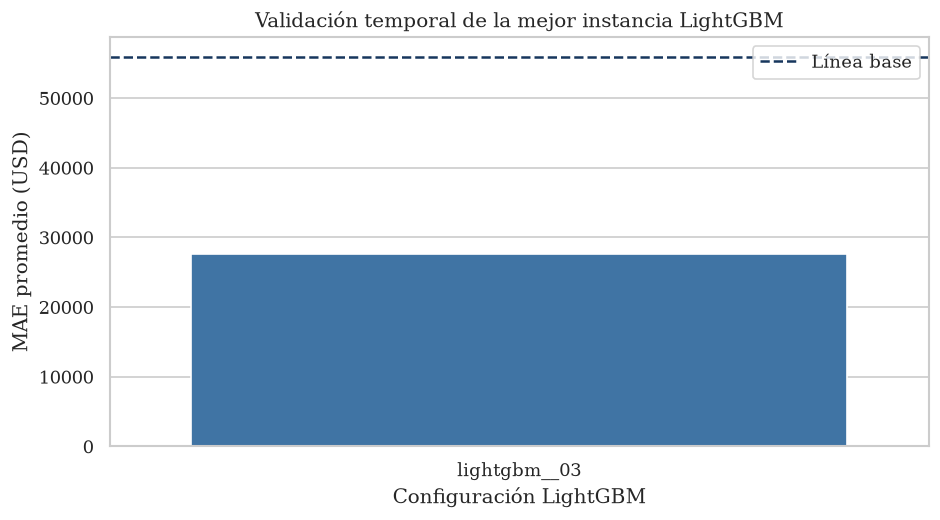

Modelo validado: LightGBM / lightgbm__03.
Mejora frente a la línea base: 50.7%.
El retrotest obtuvo MAE USD 25,013 y la validación USD 27,556; la diferencia relativa es 10.2%.
Estabilidad temporal dentro del umbral del 25%: True
Diagnóstico de subajuste: sin evidencia fuerte
Diagnóstico de sobreajuste: sin evidencia temporal fuerte


In [7]:
fig,ax=plt.subplots(figsize=(8,4.5))
sns.barplot(data=leaderboard,x='configuracion',y='val_mae_promedio',color='#2F75B5',ax=ax)
ax.axhline(baseline['mae_promedio'],color='#17365D',linestyle='--',label='Línea base')
ax.set(xlabel='Configuración LightGBM',ylabel='MAE promedio (USD)',
       title='Validación temporal de la mejor instancia LightGBM')
ax.legend();plt.tight_layout();plt.show()

back_cut=int(.80*len(train_idx));back_train,back_eval=train_idx[:back_cut],train_idx[back_cut:]
back_result,_,_=fit_and_evaluate('retrotest_'+winner,selected_params,
                                 back_train,back_eval,stage='retrotest_temporal')
back_mae=back_result['val_mae_promedio'];temporal_gap=(selected_row.val_mae_promedio-back_mae)/back_mae
stable=bool(abs(temporal_gap)<=.25)
print(f'Modelo validado: LightGBM / {winner}.')
print(f'Mejora frente a la línea base: {selected_row.mejora_vs_baseline:.1%}.')
print(f'El retrotest obtuvo MAE USD {back_mae:,.0f} y la validación USD {selected_row.val_mae_promedio:,.0f}; '
      f'la diferencia relativa es {temporal_gap:.1%}.')
print('Estabilidad temporal dentro del umbral del 25%:',stable)
print('Diagnóstico de subajuste:','sin evidencia fuerte' if selected_row.mejora_vs_baseline>=.10 else 'revisar capacidad')
print('Diagnóstico de sobreajuste:','sin evidencia temporal fuerte' if stable else 'requiere mayor regularización')


## 8. Entrenamiento definitivo y evaluación temporal reservada

Después de confirmar la configuración sin observar la prueba, unimos entrenamiento y validación, ajustamos nuevamente los dos modelos LightGBM —uno para Y1 y otro para Y2— y evaluamos una sola vez sobre el periodo más reciente. Esta cifra representa la estimación más realista del desempeño esperado ante vacantes nuevas del mismo origen. Adicionalmente calculamos en validación un margen conjunto de incertidumbre con cobertura nominal del 80%; este margen no cambia Y1/Y2, sino que informa cuánto pueden variar frente a vacantes futuras.


In [8]:
trainval_idx=train_idx.append(val_idx)
validation_true=model_df.loc[val_idx,TARGETS].to_numpy()
validation_error=np.max(np.abs(validation_true-candidate_predictions[winner]),axis=1)
uncertainty_margin=float(np.quantile(validation_error,.80,method='higher'))
final_result,final_models,test_prediction=fit_and_evaluate(
    'definitivo_'+winner,selected_params,trainval_idx,test_idx,stage='prueba_final')
final_run_id=str(final_result['run_id'])
test_scores={key.removeprefix('val_'):value for key,value in final_result.items() if key.startswith('val_')}
test_true=model_df.loc[test_idx,TARGETS].to_numpy()
uncertainty_coverage=float(np.mean(np.max(np.abs(test_true-test_prediction),axis=1)<=uncertainty_margin))
display(pd.Series(test_scores).rename('prueba_final'))
print(f'Modelo definitivo: LightGBM / {winner}.')
print(f"MAE promedio final: USD {test_scores['mae_promedio']:,.0f}. "
      f"R² mínimo/máximo: {test_scores['r2_min']:.3f}/{test_scores['r2_max']:.3f}.")
print(f'Margen conjunto de incertidumbre: ±USD {uncertainty_margin:,.0f}; '
      f'cobertura observada en prueba: {uncertainty_coverage:.1%}.')


mae_min                   22457.269671
rmse_min                  40209.631522
mape_min                      0.275313
r2_min                        0.569704
mae_max                   31627.320720
rmse_max                  54010.326578
mape_max                      0.245750
r2_max                        0.625510
mae_promedio              27042.295195
mae_amplitud              20582.656337
cobertura_intervalo           0.108714
incoherencia_raw              0.013211
prediccion_no_positiva        0.000000
Name: prueba_final, dtype: float64

Modelo definitivo: LightGBM / lightgbm__03.
MAE promedio final: USD 27,042. R² mínimo/máximo: 0.570/0.626.
Margen conjunto de incertidumbre: ±USD 52,785; cobertura observada en prueba: 79.9%.


## 9. Calidad de predicciones nuevas

Verificamos que todas las predicciones sean finitas, positivas, estén ordenadas y permanezcan dentro de los límites aprendidos. Además probamos un perfil completamente nuevo para comprobar que el codificador pueda procesar un país, empresa y cargo no observados sin producir errores ni valores incoherentes.

In [9]:
def predict_range(features):
    missing=set(X.columns)-set(features.columns)
    if missing:raise ValueError(f'Faltan variables: {sorted(missing)}')
    raw=np.column_stack([np.expm1(model.predict(features[X.columns])) for model in final_models])
    prediction=postprocess(raw)
    if not np.isfinite(prediction).all():raise ValueError('La predicción contiene valores no finitos')
    return prediction

def predict_with_uncertainty(features):
    prediction=predict_range(features)
    lower=np.maximum(train_limits['floor'],prediction-uncertainty_margin)
    upper=np.minimum(train_limits['ceiling'],prediction+uncertainty_margin)
    return prediction,lower,upper

checks={'valores_finitos':bool(np.isfinite(test_prediction).all()),
        'valores_positivos':bool((test_prediction>0).all()),
        'rangos_ordenados':bool((test_prediction[:,0]<=test_prediction[:,1]).all()),
        'dentro_limites_operativos':bool((test_prediction>=train_limits['floor']).all() and
                                         (test_prediction<=train_limits['ceiling']).all())}
base={column:(X.loc[trainval_idx,column].mode().iloc[0] if column in cat_cols else
              float(X.loc[trainval_idx,column].median())) for column in X.columns}
new_profile=pd.DataFrame([{**base,'title':'cargo completamente nuevo','country':'pais no observado',
                           'region':'region no observada','company':'empresa no observada',
                           'experience_level':'MI','experience_years':4}])
new_prediction=predict_range(new_profile)[0]
display(pd.Series({**checks,'nuevo_y1':new_prediction[0],'nuevo_y2':new_prediction[1]}))
assert all(checks.values()) and new_prediction[0]<=new_prediction[1]

valores_finitos                       True
valores_positivos                     True
rangos_ordenados                      True
dentro_limites_operativos             True
nuevo_y1                     101173.000676
nuevo_y2                     148546.845951
dtype: object

## 10. Desempeño por geografía, experiencia y modalidad

Las métricas agregadas pueden ocultar errores concentrados. Comparamos valores observados y predichos en segmentos con al menos 50 vacantes. El sesgo se calcula como predicción menos valor observado; un resultado positivo indica sobreestimación y uno negativo subestimación. Los segmentos con menor soporte deben generar una advertencia en el tablero.

In [10]:
audit=model_df.loc[test_idx,['id','countries','experience_level','experience_years','has_remote','work_mode']].copy()
audit[['y1','y2']]=model_df.loc[test_idx,TARGETS]
audit[['pred_y1','pred_y2']]=test_prediction
audit['observado']=(audit.y1+audit.y2)/2; audit['predicho']=(audit.pred_y1+audit.pred_y2)/2
audit['error_absoluto']=abs(audit.observado-audit.predicho); audit['sesgo']=audit.predicho-audit.observado
audit['country']=audit.countries.fillna('desconocido').astype(str).str.split('|').str[0].str.strip()
audit['years_clean']=pd.to_numeric(audit.experience_years,errors='coerce').where(lambda x:x.between(0,50))
audit['years_group']=pd.cut(audit.years_clean,[-.1,2,5,10,50],labels=['0-2','3-5','6-10','11+'])
remote=audit.has_remote.fillna(False).astype(bool); work=pd.to_numeric(audit.work_mode,errors='coerce')
audit['modalidad']=np.select([~remote,work.eq(1),work.eq(2),work.eq(3)],
                             ['presencial','híbrido','remoto','remoto_global'],default='remoto_sin_detalle')

def segment_table(column,min_n=50):
    return (audit.groupby(column,dropna=False,observed=True)
            .agg(n=('id','size'),mediana_observada=('observado','median'),mediana_predicha=('predicho','median'),
                 mae=('error_absoluto','mean'),sesgo=('sesgo','mean')).query('n>=@min_n').sort_values('n',ascending=False))

country_audit=segment_table('country'); experience_audit=segment_table('experience_level')
years_audit=segment_table('years_group'); mode_audit=segment_table('modalidad')
display(country_audit.head(15).style.format({c:'USD {:,.0f}' for c in ['mediana_observada','mediana_predicha','mae','sesgo']}))
display(experience_audit.style.format({c:'USD {:,.0f}' for c in ['mediana_observada','mediana_predicha','mae','sesgo']}))
display(years_audit.style.format({c:'USD {:,.0f}' for c in ['mediana_observada','mediana_predicha','mae','sesgo']}))
display(mode_audit.style.format({c:'USD {:,.0f}' for c in ['mediana_observada','mediana_predicha','mae','sesgo']}))

novel_audit=[]
for column in ['title','company','country']:
    known=set(X.loc[trainval_idx,column])
    flag=np.where(X.loc[test_idx,column].isin(known),'conocida','nueva')
    temp=audit.assign(estado_categoria=flag).groupby('estado_categoria').agg(
        n=('id','size'),mae=('error_absoluto','mean'),sesgo=('sesgo','mean')).reset_index()
    temp.insert(0,'variable',column);novel_audit.append(temp)
novel_audit=pd.concat(novel_audit,ignore_index=True)
display(novel_audit.style.format({'mae':'USD {:,.0f}','sesgo':'USD {:,.0f}'}))

,n,mediana_observada,mediana_predicha,mae,sesgo
country,,,,,
United States,6511,"USD 167,500","USD 164,628","USD 23,752","USD -3,075"
Canada,403,"USD 103,221","USD 105,156","USD 21,323","USD -3,291"
India,163,"USD 36,974","USD 38,970","USD 32,020","USD -8,300"
desconocido,129,"USD 156,000","USD 146,393","USD 31,958","USD -2,632"
Cuba,122,"USD 235,750","USD 253,293","USD 25,501","USD 13,160"
Poland,105,"USD 80,000","USD 78,869","USD 21,279",USD 32
United Kingdom,81,"USD 102,852","USD 96,862","USD 28,202","USD -13,009"
Costa Rica,64,"USD 222,400","USD 125,398","USD 97,993","USD -97,993"
Italy,55,"USD 67,348","USD 73,346","USD 30,940","USD -10,031"


,n,mediana_observada,mediana_predicha,mae,sesgo
experience_level,,,,,
SE,5194,"USD 171,787","USD 167,247","USD 24,905","USD -3,373"
MI,2428,"USD 133,264","USD 135,528","USD 25,496","USD -3,572"
EN,416,"USD 105,858","USD 100,101","USD 28,463","USD -10,105"
EX,197,"USD 207,500","USD 202,702","USD 31,433","USD -5,732"


,n,mediana_observada,mediana_predicha,mae,sesgo
years_group,,,,,
3-5,3775,"USD 148,000","USD 148,635","USD 25,393","USD -2,393"
6-10,2929,"USD 178,850","USD 173,144","USD 25,091","USD -4,651"
0-2,1253,"USD 125,000","USD 117,926","USD 25,486","USD -5,378"
11+,294,"USD 223,768","USD 208,155","USD 29,484","USD -8,741"


,n,mediana_observada,mediana_predicha,mae,sesgo
modalidad,,,,,
presencial,5453,"USD 167,500","USD 162,576","USD 26,354","USD -5,093"
remoto,1468,"USD 125,000","USD 141,185","USD 22,788",USD -664
remoto_sin_detalle,1051,"USD 145,000","USD 145,582","USD 26,371","USD -2,417"
híbrido,270,"USD 183,225","USD 174,553","USD 18,199","USD -3,033"


,variable,estado_categoria,n,mae,sesgo
0,title,conocida,3808,"USD 20,716","USD -2,293"
1,title,nueva,4443,"USD 29,500","USD -5,229"
2,company,conocida,7097,"USD 24,386","USD -3,971"
3,company,nueva,1154,"USD 31,962","USD -3,281"
4,country,conocida,8223,"USD 25,451","USD -3,935"
5,country,nueva,28,"USD 23,844","USD 14,134"


## 11. Sensibilidad controlada de experiencia y geografía

Construimos perfiles comparables modificando una dimensión a la vez. Esta prueba no demuestra causalidad, pero permite detectar respuestas contrarias a patrones básicos del mercado. En experiencia esperamos una progresión general entre entrada, nivel medio, senior y ejecutivo. En geografía comparamos la predicción con la mediana observada y el soporte disponible en entrenamiento.

In [11]:
experience_scenarios=[]
for level,years in [('EN',1),('MI',4),('SE',8),('EX',12)]:
    experience_scenarios.append({**base,'experience_level':level,'experience_years':years})
exp_frame=pd.DataFrame(experience_scenarios)[X.columns]
exp_pred=predict_range(exp_frame)
exp_result=pd.DataFrame({'nivel':['EN','MI','SE','EX'],'años':[1,4,8,12],
                         'pred_y1':exp_pred[:,0],'pred_y2':exp_pred[:,1]})
exp_result['punto_medio']=(exp_result.pred_y1+exp_result.pred_y2)/2
exp_result['progresion_respecto_anterior']=exp_result.punto_medio.diff().fillna(0)
display(exp_result.style.format({c:'USD {:,.0f}' for c in ['pred_y1','pred_y2','punto_medio','progresion_respecto_anterior']}))

top_countries=X.loc[trainval_idx,'country'].value_counts().head(8).index
geo_frame=pd.DataFrame([{**base,'country':country} for country in top_countries])[X.columns]
geo_pred=predict_range(geo_frame); geo_result=pd.DataFrame({'country':top_countries,
    'pred_y1':geo_pred[:,0],'pred_y2':geo_pred[:,1]})
geo_result['punto_medio_predicho']=(geo_result.pred_y1+geo_result.pred_y2)/2
observed=(model_df.loc[trainval_idx].assign(country=X.loc[trainval_idx,'country'],
    midpoint=lambda d:(d.y_min_usd+d.y_max_usd)/2).groupby('country').midpoint.agg(n='size',mediana_observada='median'))
geo_result=geo_result.join(observed,on='country')
display(geo_result.style.format({c:'USD {:,.0f}' for c in ['pred_y1','pred_y2','punto_medio_predicho','mediana_observada']}))
print('Progresión de experiencia no decreciente:',bool((exp_result.punto_medio.diff().dropna()>=0).all()))

,nivel,años,pred_y1,pred_y2,punto_medio,progresion_respecto_anterior
0,EN,1,"USD 101,622","USD 145,235","USD 123,428",USD 0
1,MI,4,"USD 112,257","USD 158,508","USD 135,382","USD 11,954"
2,SE,8,"USD 148,225","USD 200,067","USD 174,146","USD 38,763"
3,EX,12,"USD 178,505","USD 237,807","USD 208,156","USD 34,010"


,country,pred_y1,pred_y2,punto_medio_predicho,n,mediana_observada
0,United States,"USD 129,501","USD 168,744","USD 149,123",41394,"USD 170,650"
1,Canada,"USD 99,860","USD 139,740","USD 119,800",1837,"USD 102,256"
2,desconocido,"USD 129,499","USD 167,739","USD 148,619",1109,"USD 145,000"
3,United Kingdom,"USD 104,328","USD 142,728","USD 123,528",523,"USD 94,870"
4,Germany,"USD 105,446","USD 160,642","USD 133,044",199,"USD 120,000"
5,India,"USD 65,998","USD 99,885","USD 82,941",195,"USD 36,748"
6,Poland,"USD 82,709","USD 123,672","USD 103,190",124,"USD 73,597"
7,Lithuania,"USD 80,747","USD 125,193","USD 102,970",107,"USD 66,548"


Progresión de experiencia no decreciente: True


## 12. Habilidades, conocimientos e importancia de variables

Comparamos perfiles con grupos crecientes de habilidades manteniendo constantes las demás características. No imponemos que cada herramienta incremente el salario, porque su presencia es una asociación y depende del cargo y del mercado. La importancia del modelo se utiliza para entender qué variables participan con mayor frecuencia, no como una medida causal.

,escenario,pred_y1,pred_y2,punto_medio
0,sin_habilidades,"USD 125,028","USD 167,665","USD 146,347"
1,python_sql,"USD 132,201","USD 174,151","USD 153,176"
2,datos_nube,"USD 132,332","USD 167,353","USD 149,843"
3,mlops,"USD 139,139","USD 186,215","USD 162,677"


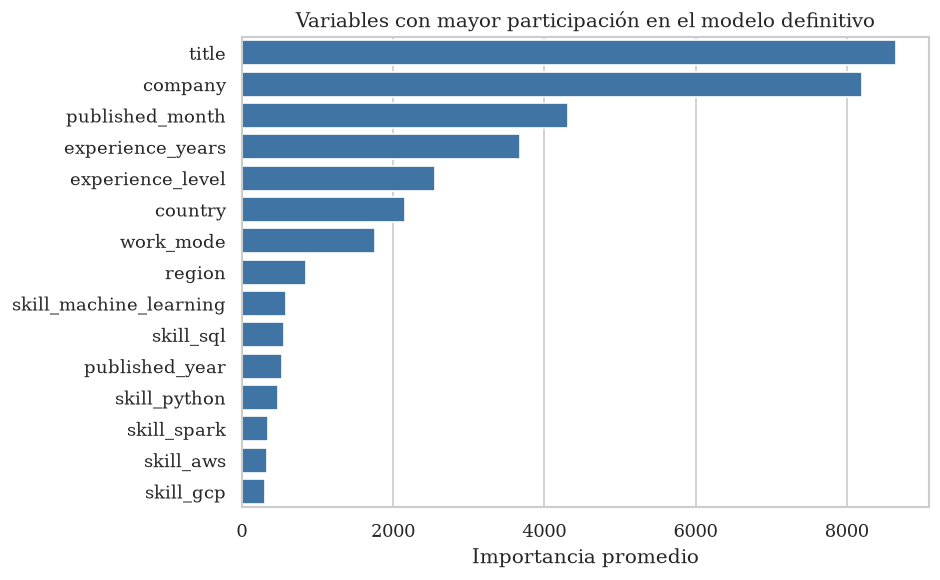

,variable,importancia
0,title,8652.5
5,company,8207.0
23,published_month,4312.0
7,experience_years,3680.5
3,experience_level,2552.5
1,country,2164.0
4,work_mode,1755.0
2,region,850.5
17,skill_machine_learning,582.5
10,skill_sql,553.5


In [12]:
skill_sets={'sin_habilidades':[], 'python_sql':['python','sql'],
            'datos_nube':['python','sql','aws','spark'],
            'mlops':['python','machine_learning','docker','kubernetes','aws']}
skill_rows=[]
for label,skills in skill_sets.items():
    row={**base}
    for skill in SKILLS:row[f'skill_{skill}']=int(skill in skills)
    row['escenario']=label;skill_rows.append(row)
skill_frame=pd.DataFrame(skill_rows)
skill_pred=predict_range(skill_frame[X.columns])
skill_result=pd.DataFrame({'escenario':skill_frame.escenario,'pred_y1':skill_pred[:,0],'pred_y2':skill_pred[:,1]})
skill_result['punto_medio']=(skill_result.pred_y1+skill_result.pred_y2)/2
display(skill_result.style.format({c:'USD {:,.0f}' for c in ['pred_y1','pred_y2','punto_medio']}))

if selected_model=='catboost':
    feature_names=np.asarray(X.columns);importance=np.mean([model.feature_importances_ for model in final_models],axis=0)
else:
    feature_names=final_models[0].named_steps['preprocesamiento'].get_feature_names_out()
    estimators=[model.named_steps['modelo'] for model in final_models]
    if selected_model=='ridge':importance=np.mean([np.abs(model.coef_) for model in estimators],axis=0)
    else:importance=np.mean([model.feature_importances_ for model in estimators],axis=0)
importance_df=pd.DataFrame({'variable':feature_names,'importancia':importance}).sort_values('importancia',ascending=False)
fig,ax=plt.subplots(figsize=(8,5))
sns.barplot(data=importance_df.head(15),y='variable',x='importancia',color='#2F75B5',ax=ax)
ax.set(xlabel='Importancia promedio',ylabel='',title='Variables con mayor participación en el modelo definitivo')
plt.tight_layout();plt.show()
display(importance_df.head(15))

## 13. Conclusiones del modelo definitivo

La comparación de familias y la búsqueda de hiperparámetros se realiza en el notebook 05. Allí LightGBM queda seleccionado dentro del grupo de alternativas equivalentes en MAE promedio, con prioridad sobre el menor error del límite superior y compatibilidad con el pipeline. En este notebook se utiliza únicamente esa instancia para evitar repetir la selección sobre la prueba reservada.

La configuración se acompaña de un diagnóstico independiente de estabilidad. La evidencia debe mostrar si supera la línea base, cómo cambia entre ventanas futuras y si produce rangos positivos y ordenados. La evaluación por segmentos permite identificar mercados o niveles de experiencia donde el error continúa siendo alto; estos resultados deben convertirse en advertencias de cobertura en el tablero.

Las diferencias por geografía, experiencia o habilidades representan asociaciones presentes en publicaciones laborales. No deben interpretarse como efectos causales ni como una recomendación salarial individual. La versión desplegada deberá conservar la fecha, las métricas, los límites operativos y los conteos de soporte utilizados en este notebook.

La prueba final se publica como una corrida de evaluación en MLflow, pero este notebook no crea una versión en el Model Registry ni modifica el alias `champion`. Los hiperparámetros aprobados deben trasladarse a `params.yaml` antes de ejecutar `dvc repro`, `track` y `register-candidate`; la promoción al alias se realiza únicamente después de validar la versión registrada.


In [13]:
support={'country':X.loc[trainval_idx,'country'].value_counts().to_dict(),
         'experience_level':X.loc[trainval_idx,'experience_level'].value_counts().to_dict(),
         'work_mode':X.loc[trainval_idx,'work_mode'].value_counts().to_dict()}
eligible_notebook=bool(selected_row.mejora_vs_baseline>=.10 and stable and all(checks.values()))
pipeline_compatible=True
bundle={'version':'modelo-definitivo-v3','created_at':pd.Timestamp.utcnow().isoformat(),
        'comparison_input':comparison_selection,
        'model_family':selected_model,'model_class':type(final_models[0]).__name__,
        'configuration':winner,'parameters':selected_params,
        'selection_rule':comparison_selection['criterio_aplicado'],
        'generalization_diagnostic':{'backtest_mae':back_mae,'validation_mae':selected_row.val_mae_promedio,
                                     'relative_gap':temporal_gap,'within_25_percent':stable},
        'uncertainty':{'method':'residuo conjunto calibrado en validación','nominal_coverage':.80,
                       'margin_usd':uncertainty_margin,'test_coverage':uncertainty_coverage},
        'target_scope':'rangos completamente reportados','targets':TARGETS,'feature_columns':list(X.columns),
        'categorical_columns':cat_cols,'skills':SKILLS,'limits':train_limits,'support':support,
        'validation_results':leaderboard.to_dict(orient='records'),
        'test_metrics':test_scores,
        'mlflow':{'tracking_uri_source':'MLFLOW_TRACKING_URI','experiment_name':EXPERIMENT_NAME,
                  'run_id':final_run_id,'registered_model_name':REGISTERED_MODEL_NAME,
                  'production_alias':PRODUCTION_ALIAS},
        'eligible_notebook':eligible_notebook,
        'models':dict(zip(TARGETS,final_models)),'seed':SEED}
model_path=ARTIFACT_DIR/'salary_range_model_final.joblib'
predictions_path=ARTIFACT_DIR/'predicciones_prueba_final.csv'
metrics_path=ARTIFACT_DIR/'metricas_modelo_final.json'
handoff_path=ARTIFACT_DIR/'traspaso_pipeline_modelo_final.json'
joblib.dump(bundle,model_path,compress=3)
pd.DataFrame({'id':model_df.loc[test_idx,'id'].astype(str),'y_min':model_df.loc[test_idx,'y_min_usd'],
              'y_max':model_df.loc[test_idx,'y_max_usd'],'pred_min':test_prediction[:,0],
              'pred_max':test_prediction[:,1]}).to_csv(predictions_path,index=False)
with open(metrics_path,'w') as file:
    json.dump({'selected_model':selected_model,'configuration':winner,'parameters':selected_params,
               'selection_diagnostics':comparison_selection,'test_metrics':test_scores,
               'quality_checks':checks,'eligible_notebook':eligible_notebook,
               'mlflow_run_id':final_run_id},file,indent=2,default=str)
handoff={'source_notebook':'06_modelo_definitivo_fjlo.ipynb',
         'selected_model':selected_model,'selected_configuration':winner,
         'parameters':selected_params,'validation_selection':comparison_selection,
         'test_metrics':test_scores,'eligible_notebook':eligible_notebook,
         'pipeline_compatible':pipeline_compatible,
         'pipeline_note':'Actualizar params.yaml y ejecutar dvc repro antes de track.',
         'mlflow_run_id':final_run_id,'registered_model_name':REGISTERED_MODEL_NAME,
         'production_alias':PRODUCTION_ALIAS,'tracking_uri_source':'MLFLOW_TRACKING_URI'}
with open(handoff_path,'w') as file:
    json.dump(handoff,file,indent=2,default=str)
mlflow_client.set_tag(final_run_id,'estado_evaluacion','prueba_final_completada')
mlflow_client.set_tag(final_run_id,'eligible_notebook',str(eligible_notebook).lower())
mlflow_client.set_tag(final_run_id,'pipeline_compatible',str(pipeline_compatible).lower())
mlflow_client.set_tag(final_run_id,'familia_seleccionada',selected_model)
for artifact_path in [model_path,predictions_path,metrics_path,handoff_path]:
    mlflow_client.log_artifact(final_run_id,str(artifact_path),artifact_path='modelo_definitivo_notebook_06')
print('Modelo definitivo:',model_path)
print('Familia seleccionada:',selected_model)
print('Corrida definitiva publicada en MLflow:',final_run_id)
print('Elegible según controles del notebook:',eligible_notebook)
print('Compatibilidad con el pipeline productivo actual:',pipeline_compatible)

Modelo definitivo: /Users/franciscolozano/Downloads/PROYECTOS_MAIA/PROYECTO_DE_GRADO/MICROPROYECTO_GITHUB/ml/artifacts/salary_range_model_final.joblib
Familia seleccionada: lightgbm
Corrida definitiva publicada en MLflow: 570a36e611af4546aaed3876d8135cda
Elegible según controles del notebook: True
Compatibilidad con el pipeline productivo actual: True
